Color      | λ (µm)   | n(λ)     | Exit Angle
--------------------------------------------------
Violet     | 0.40     | 1.5250 | 56.10°
Blue       | 0.45     | 1.5198 | 53.16°
Cyan       | 0.50     | 1.5160 | 51.66°
Green      | 0.55     | 1.5132 | 50.71°
Yellow     | 0.58     | 1.5119 | 50.29°
Orange     | 0.62     | 1.5104 | 49.83°
Red        | 0.70     | 1.5082 | 49.19°

Success! Figure saved to: figures/prism_dispersion.png


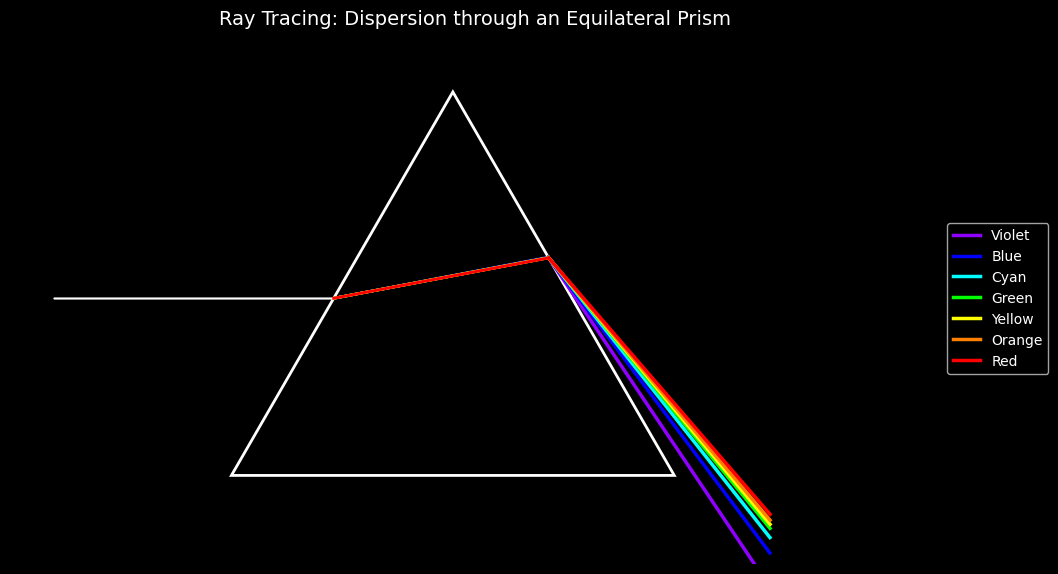

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. SETUP DATA & DISPERSION FORMULA
wavelengths = [0.40, 0.45, 0.50, 0.55, 0.58, 0.62, 0.70]
colors = ['#8F00FF', '#0000FF', '#00FFFF', '#00FF00', '#FFFF00', '#FF7F00', '#FF0000']
names = ["Violet", "Blue", "Cyan", "Green", "Yellow", "Orange", "Red"]

def get_n(wl):
    return 1.50 + (0.004 / (wl**2))

# 2. SETUP FIGURE (Dark Aesthetic)
fig, ax = plt.subplots(figsize=(12, 8), facecolor='black')
ax.set_facecolor('black')

# Define Prism Vertices (Equilateral)
v1 = np.array([0, 0])
v2 = np.array([10, 0])
v3 = np.array([5, 8.66])
prism_poly = plt.Polygon([v1, v2, v3], closed=True, edgecolor='white', fill=False, lw=2)
ax.add_patch(prism_poly)

# 3. RAY TRACING LOGIC
print(f"{'Color':<10} | {'λ (µm)':<8} | {'n(λ)':<8} | {'Exit Angle'}")
print("-" * 50)

for wl, color, name in zip(wavelengths, colors, names):
    n = get_n(wl)
    
    # --- Surface 1 (Left Face) ---
    # Incident light enters horizontally (0°). 
    # Left face normal is at 30° to horizontal.
    theta_i1 = np.radians(30)
    theta_r1 = np.arcsin(np.sin(theta_i1) / n)
    
    # --- Surface 2 (Right Face) ---
    # Internal geometry: theta_i2 = 60° - theta_r1
    theta_i2 = np.radians(60) - theta_r1
    theta_r2 = np.arcsin(n * np.sin(theta_i2))
    
    # Final Direction (Relative to horizontal)
    # Deviation = theta_r2 - 30°
    exit_angle_deg = np.degrees(theta_r2 - np.radians(30))
    print(f"{name:<10} | {wl:<8.2f} | {n:.4f} | {exit_angle_deg:.2f}°")

    # --- COORDINATES FOR PLOTTING ---
    # p1: Entry point on left face (x ~ 2.31, y = 4.0)
    p1 = np.array([2.31, 4.0])
    
    # p2: Intersection with Right Face
    # Ray line inside: y - 4 = tan(30 - theta_r1) * (x - 2.31)
    # Face line: y = -1.732x + 17.32
    m_ray = np.tan(np.radians(30) - theta_r1)
    x2 = (17.32 - (p1[1] - m_ray * p1[0])) / (1.732 + m_ray)
    y2 = m_ray * (x2 - p1[0]) + p1[1]
    p2 = np.array([x2, y2])
    
    # p3: Exit Path (extends 5 units out)
    m_out = np.tan(-np.radians(exit_angle_deg))
    p3 = p2 + np.array([5, 5 * m_out])

    # Draw the segments
    ax.plot([-4, p1[0]], [4, 4], color='white', lw=1, alpha=0.6) # Incoming White Light
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, lw=2)    # Inside Prism
    ax.plot([p2[0], p3[0]], [p2[1], p3[1]], color=color, lw=2.5, label=name) # Exit Ray

# 4. FINAL FORMATTING
ax.set_aspect('equal')
ax.set_xlim(-5, 16)
ax.set_ylim(-2, 10)
ax.axis('off') 
plt.title("Ray Tracing: Dispersion through an Equilateral Prism", color='white', fontsize=14)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), facecolor='black', labelcolor='white')

# 5. THE SAVING BLOCK (Bulletproof)
folder_name = "figures"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

file_path = os.path.join(folder_name, "prism_dispersion.png")

# Save the figure BEFORE showing it
fig.savefig(file_path, 
            bbox_inches='tight', 
            dpi=300, 
            facecolor=fig.get_facecolor(), 
            edgecolor='none')

print(f"\nSuccess! Figure saved to: {file_path}")

# Display in Jupyter
plt.show()